In [1]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from collections import Counter

In [2]:
# Load Dataset & Basic Inspection
df = pd.read_excel("drugsCom_raw.xlsx")
df.head()

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37


In [3]:
# Dataset information: rows, columns, data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Unnamed: 0   161297 non-null  int64         
 1   drugName     161297 non-null  object        
 2   condition    160398 non-null  object        
 3   review       161297 non-null  object        
 4   rating       161297 non-null  int64         
 5   date         161297 non-null  datetime64[ns]
 6   usefulCount  161297 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 8.6+ MB


In [4]:
# Check missing values in each column
df.isnull().sum()

Unnamed: 0       0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [5]:
# Conditions selected for this project
conditions = ['Depression', 'High Blood Pressure', 'Diabetes, Type 2']

# Filter dataset
df = df[df['condition'].isin(conditions)]

# Count reviews per condition
df['condition'].value_counts()


condition
Depression             9069
Diabetes, Type 2       2554
High Blood Pressure    2321
Name: count, dtype: int64

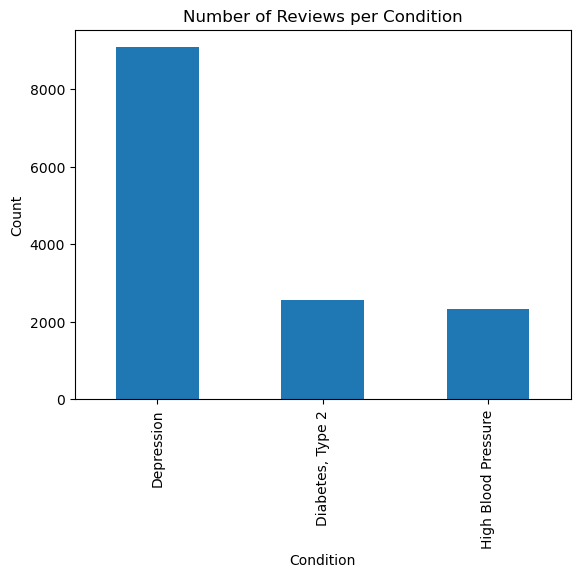

In [6]:
# Visualize condition distribution
df['condition'].value_counts().plot(kind='bar')
plt.title("Number of Reviews per Condition")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()


In [7]:
# Remove rows with missing reviews (text is mandatory)
df.dropna(subset=['review'], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Recheck missing values
df.isnull().sum()


Unnamed: 0     0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
dtype: int64

<Figure size 640x480 with 0 Axes>

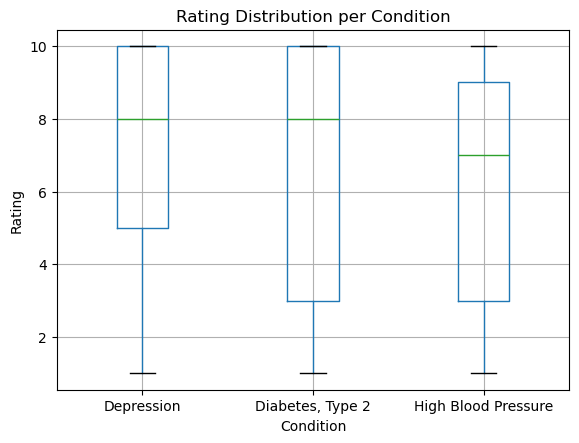

In [8]:
# Boxplot of ratings per condition
plt.figure()
df.boxplot(column='rating', by='condition')
plt.title("Rating Distribution per Condition")
plt.xlabel("Condition")
plt.ylabel("Rating")
plt.suptitle("")
plt.show()


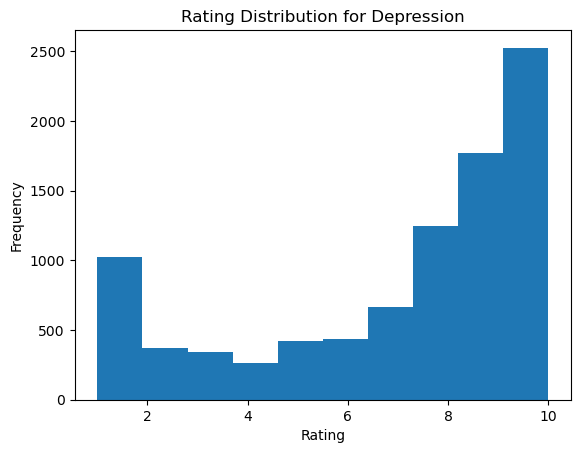

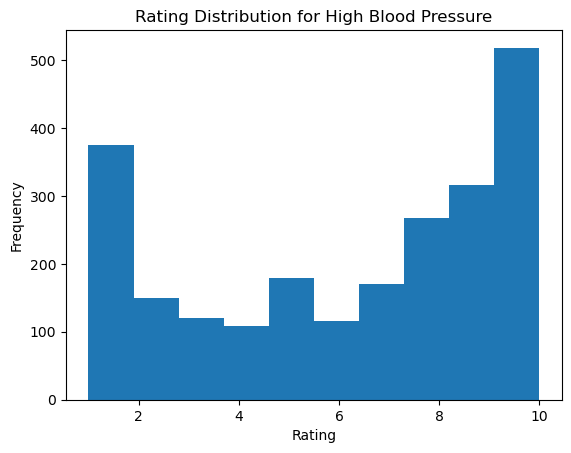

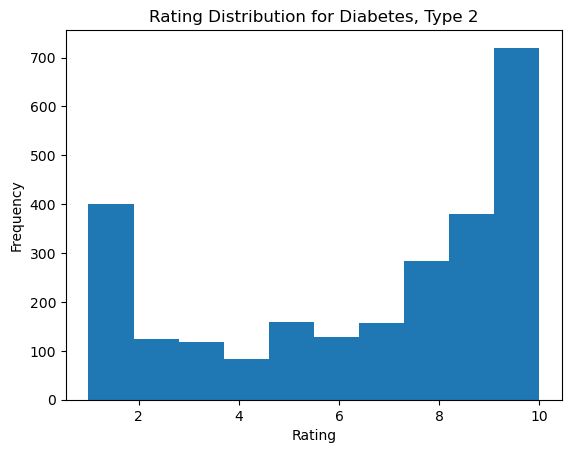

In [9]:
# Rating distribution per condition
for con in conditions:
    plt.figure()
    df[df['condition'] == con]['rating'].plot(kind='hist', bins=10)
    plt.title(f"Rating Distribution for {con}")
    plt.xlabel("Rating")
    plt.ylabel("Frequency")
    plt.show()
    
# These plots help compare satisfaction levels across conditions

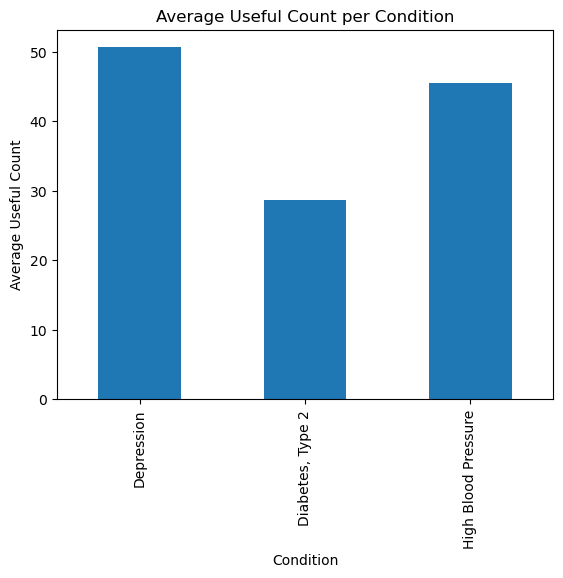

In [10]:
# Average useful count per condition

plt.figure()
df.groupby('condition')['usefulCount'].mean().plot(kind='bar')
plt.title("Average Useful Count per Condition")
plt.xlabel("Condition")
plt.ylabel("Average Useful Count")
plt.show()

# Reviews with higher usefulCount are considered more reliable by users

In [11]:

df['clean_review'] = df['review'].str.lower()

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'https\S+|www\.\S+', '', text)
    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Apply text cleaning
df['clean_review'] = df['clean_review'].apply(clean_text)

# View result
df['clean_review'].head()


11    i have taken antidepressants for years with so...
31    1 week on zoloft for anxiety and mood swings i...
44    my gp started me on venlafaxine yesterday to h...
50    hey guys  it039s been 4 months since my last p...
67    this medicine saved my life i was at my wits e...
Name: clean_review, dtype: object

In [12]:
# Stopwords are removed since they do not add meaning
df['clean_review'] = df['clean_review'].apply(lambda x: x.split())
df['clean_review'].head()

11    [i, have, taken, antidepressants, for, years, ...
31    [1, week, on, zoloft, for, anxiety, and, mood,...
44    [my, gp, started, me, on, venlafaxine, yesterd...
50    [hey, guys, it039s, been, 4, months, since, my...
67    [this, medicine, saved, my, life, i, was, at, ...
Name: clean_review, dtype: object

In [13]:
# Load stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Stopwords are removed since they do not add meaning
df['clean_review'] = df['clean_review'].apply(
    lambda words: [w for w in words if w not in stop_words]
)
df['clean_review'].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pranavobili/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


11    [taken, antidepressants, years, improvement, m...
31    [1, week, zoloft, anxiety, mood, swings, take,...
44    [gp, started, venlafaxine, yesterday, help, de...
50    [hey, guys, it039s, 4, months, since, last, po...
67    [medicine, saved, life, wits, end, antidepress...
Name: clean_review, dtype: object

In [14]:
# Lemmatization converts words to base form
# Download WordNet
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Lemmatize words
df['clean_review'] = df['clean_review'].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)
# Convert tokens back to text
df['clean_review'] = df['clean_review'].apply(lambda x: ' '.join(x))
df['clean_review'].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/pranavobili/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


11    taken antidepressant year improvement mostly m...
31    1 week zoloft anxiety mood swing take 50mg mor...
44    gp started venlafaxine yesterday help depressi...
50    hey guy it039s 4 month since last post wanted ...
67    medicine saved life wit end antidepressant rea...
Name: clean_review, dtype: object

In [15]:
# Preview cleaned text
df[['review', 'clean_review']].head()

,review,clean_review
11,"""I have taken anti-depressants for years, with...",taken antidepressant year improvement mostly m...
31,"""1 week on Zoloft for anxiety and mood swings....",1 week zoloft anxiety mood swing take 50mg mor...
44,"""my gp started me on Venlafaxine yesterday to ...",gp started venlafaxine yesterday help depressi...
50,"""Hey Guys, It&#039;s been 4 months since my l...",hey guy it039s 4 month since last post wanted ...
67,"""This medicine saved my life. I was at my wits...",medicine saved life wit end antidepressant rea...


In [16]:
# Combine all words
all_words = " ".join(df['clean_review']).split()
word_freq = Counter(all_words) # Count word frequency

# Top 20 words
word_freq.most_common(20)


[('day', 7373),
 ('effect', 6811),
 ('side', 6227),
 ('week', 6126),
 ('year', 5897),
 ('taking', 5738),
 ('depression', 5624),
 ('feel', 5424),
 ('month', 5031),
 ('started', 4311),
 ('i039m', 4167),
 ('time', 4038),
 ('medication', 4032),
 ('like', 3892),
 ('i039ve', 3671),
 ('take', 3661),
 ('first', 3593),
 ('anxiety', 3541),
 ('life', 3141),
 ('blood', 3122)]

In [17]:
# Top words per condition
for condition in df['condition'].unique():
    words = " ".join(df[df['condition'] == condition]['clean_review']).split()
    freq = Counter(words)
    print(f"\nTop words for {condition}:")
    print(freq.most_common(10))



Top words for Depression:
[('depression', 5565), ('day', 5010), ('effect', 4582), ('feel', 4457), ('year', 4311), ('week', 4201), ('side', 4023), ('taking', 3845), ('month', 3454), ('anxiety', 3425)]

Top words for Diabetes, Type 2:
[('sugar', 1490), ('week', 1407), ('day', 1389), ('blood', 1067), ('month', 1049), ('effect', 1003), ('side', 1000), ('started', 863), ('taking', 862), ('weight', 832)]

Top words for High Blood Pressure:
[('pressure', 1861), ('blood', 1818), ('effect', 1226), ('side', 1204), ('taking', 1031), ('day', 974), ('year', 950), ('doctor', 684), ('medicine', 673), ('bp', 634)]


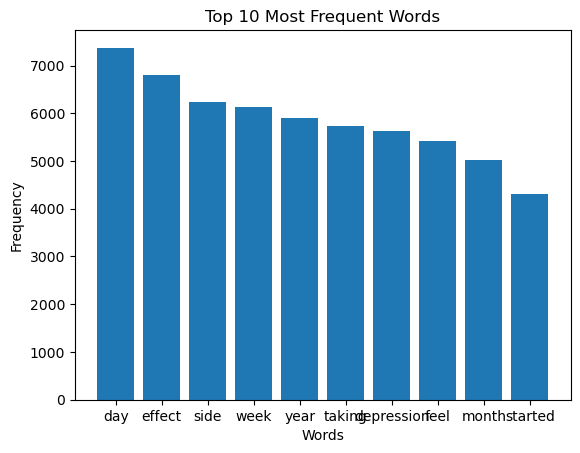

In [18]:
# Plot top 10 frequent words
top_words = word_freq.most_common(10)
words, counts = zip(*top_words)

plt.figure()
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


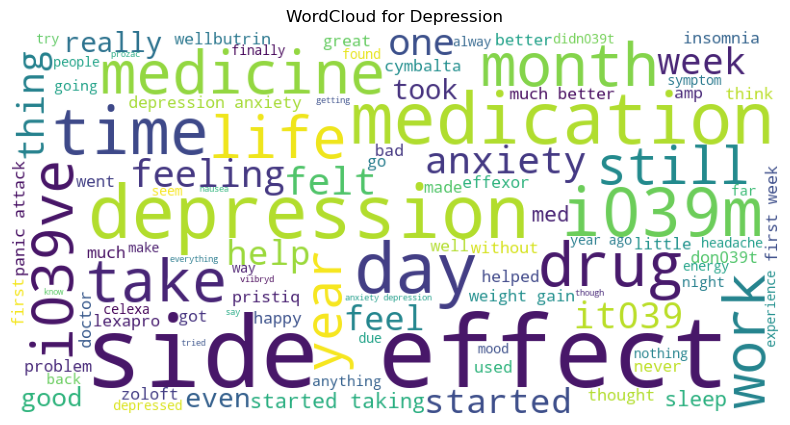

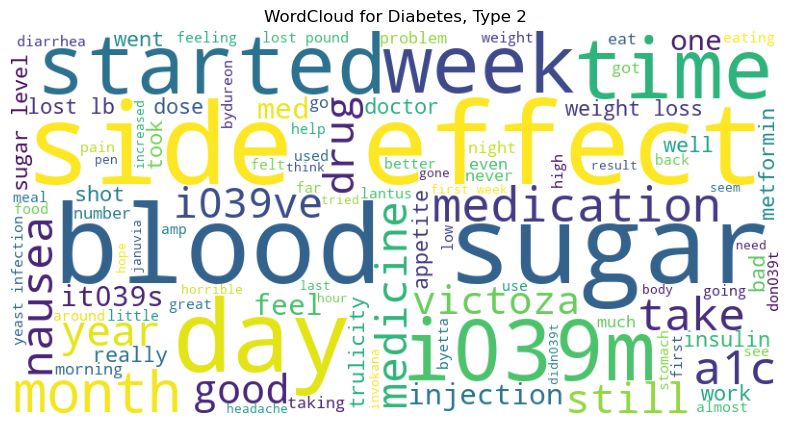

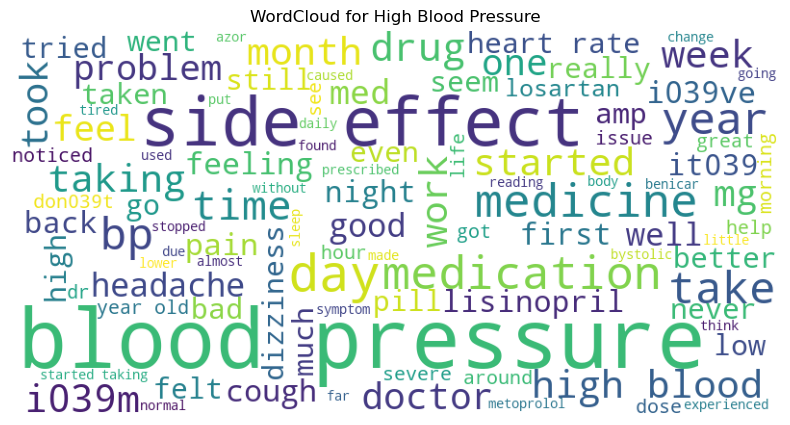

In [19]:
# Word clouds give a visual overview of dominant terms.
from wordcloud import WordCloud


# Loop through each condition
for condition in df['condition'].unique():
    
    # Combine all reviews of one condition
    text = " ".join(df[df['condition'] == condition]['clean_review'])
    
    # Create WordCloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100
    ).generate(text)
    
    # Plot WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"WordCloud for {condition}")
    plt.show()


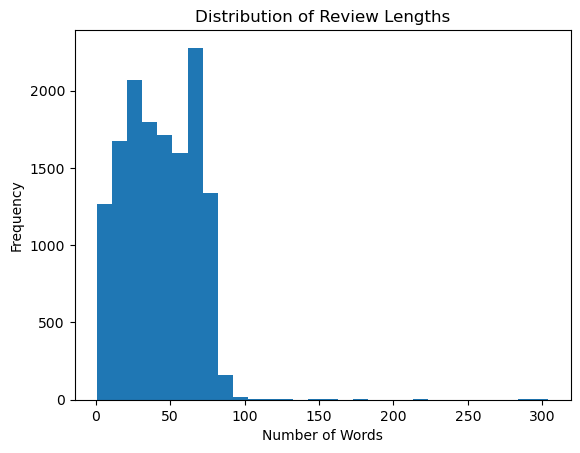

In [20]:
# Calculate review length
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

# Plot review length distribution
df['review_length'].plot(kind='hist', bins=30)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [21]:
# Lexicon-based sentiment helps understand patient emotions.
# Download VADER lexicon
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
# Calculate sentiment score
df['sentiment_score'] = df['clean_review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/pranavobili/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


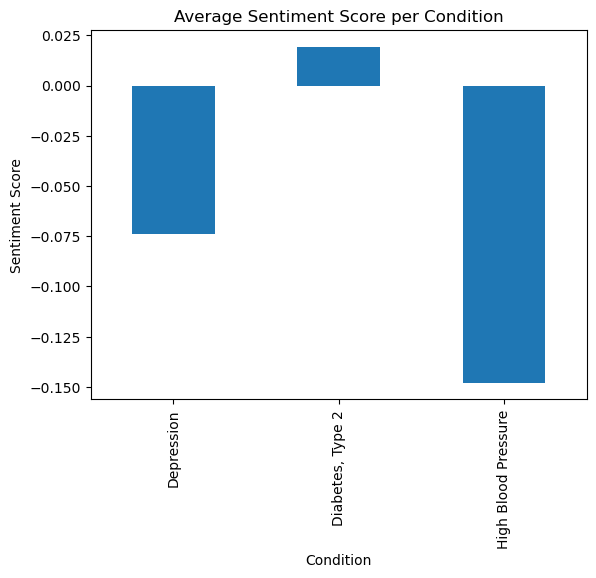

In [22]:
# Average sentiment per condition
df.groupby('condition')['sentiment_score'].mean().plot(kind='bar')
plt.title("Average Sentiment Score per Condition")
plt.xlabel("Condition")
plt.ylabel("Sentiment Score")
plt.show()


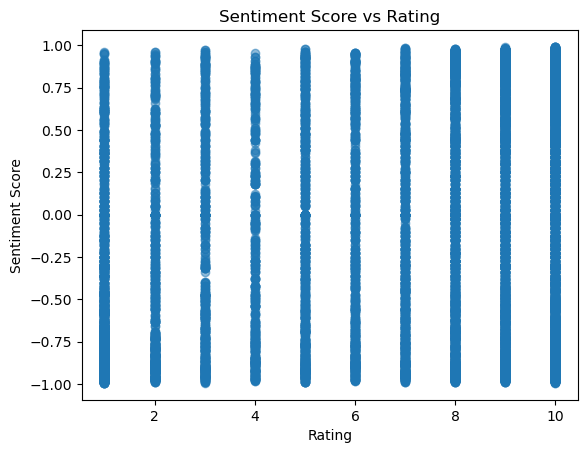

In [23]:
# Sentiment vs Rating
plt.figure()
plt.scatter(df['rating'], df['sentiment_score'], alpha=0.5)
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.title("Sentiment Score vs Rating")
plt.show()


In [24]:
"""
We explored and cleaned the data, analyzed ratings and text patterns, 
used lexicon-based sentiment for understanding emotions, and 
confirmed that the dataset is suitable for NLP-based classificatioy 
for feature extraction and modeling in the next phase

"""

'\nWe explored and cleaned the data, analyzed ratings and text patterns, \nused lexicon-based sentiment for understanding emotions, and \nconfirmed that the dataset is suitable for NLP-based classificatioy \nfor feature extraction and modeling in the next phase\n\n'

In [25]:
# We ensured there are no empty reviews before modeling
# Make sure there are no empty reviews
df = df[df['clean_review'].str.strip() != ""]

# Reset index
df.reset_index(drop=True, inplace=True)
df.head()

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount,clean_review,review_length,sentiment_score
0,75612,L-methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,2017-03-09,54,taken antidepressant year improvement mostly m...,43,0.5994
1,96233,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,2011-05-07,3,1 week zoloft anxiety mood swing take 50mg mor...,29,0.2960
2,121333,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,2016-04-27,3,gp started venlafaxine yesterday help depressi...,69,-0.6908
3,156544,Dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,2017-10-24,24,hey guy it039s 4 month since last post wanted ...,68,0.3400
4,131909,Effexor XR,Depression,"""This medicine saved my life. I was at my wits...",10,2013-06-20,166,medicine saved life wit end antidepressant rea...,49,0.8101


In [26]:
# Convert rating into sentiment labels
def rating_to_sentiment(rating):
    if rating >= 7:
        return 'Positive'
    elif rating >= 4:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df['sentiment'].value_counts() # Check sentiment distribution


sentiment
Positive    9021
Negative    3029
Neutral     1894
Name: count, dtype: int64

In [27]:
# Conditions are encoded into numerical labels for supervised learning
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['condition_label'] = le.fit_transform(df['condition'])

df[['condition', 'condition_label']].drop_duplicates()
df[['condition', 'condition_label']].value_counts()

condition            condition_label
Depression           0                  9069
Diabetes, Type 2     1                  2554
High Blood Pressure  2                  2321
Name: count, dtype: int64

In [28]:
# Define features (X) and target (y)
x = df['clean_review']
y = df['condition_label']

x.shape, y.shape


((13944,), (13944,))

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)


In [30]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

x_train_tfidf.shape, x_test_tfidf.shape


((11155, 5000), (2789, 5000))

In [31]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, f1_score

models = {
    "Naive Bayes": MultinomialNB(),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    
    "Linear SVM": LinearSVC(
        class_weight='balanced'
    ),
    
    "SGD Classifier": SGDClassifier(
        loss='hinge',
        class_weight='balanced',
        random_state=42
    )
}


In [32]:
results = []

for name, model in models.items():
    
    # Train
    model.fit(x_train_tfidf, y_train)
    
    # Predict
    y_pred = model.predict(x_test_tfidf)
    
    # Metrics
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "F1_macro": f1,
        "Accuracy": acc
    })
    
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))



Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1814
           1       0.97      0.90      0.93       511
           2       0.95      0.79      0.86       464

    accuracy                           0.94      2789
   macro avg       0.95      0.89      0.92      2789
weighted avg       0.94      0.94      0.94      2789


Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1814
           1       0.92      0.95      0.93       511
           2       0.89      0.91      0.90       464

    accuracy                           0.95      2789
   macro avg       0.93      0.94      0.94      2789
weighted avg       0.95      0.95      0.95      2789


Linear SVM Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1814
           

In [33]:
results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
results_df


,Model,F1_macro,Accuracy
2,Linear SVM,0.945971,0.961635
3,SGD Classifier,0.941714,0.958049
1,Logistic Regression,0.936224,0.953030
0,Naive Bayes,0.919484,0.941198


In [34]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print("Selected Final Model:", best_model_name)


Selected Final Model: Linear SVM


In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

svm = LinearSVC(class_weight='balanced')

grid = GridSearchCV(
    svm,
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid.fit(x_train_tfidf, y_train)

print("Best C:", grid.best_params_)
print("Best F1:", grid.best_score_)


Best C: {'C': 1}
Best F1: 0.9487312736909794


In [36]:
# Set final tuned model
best_model = grid.best_estimator_
print("Final Model: Tuned Linear SVM with C =", grid.best_params_['C'])


Final Model: Tuned Linear SVM with C = 1


In [37]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Predict on test set
y_pred = best_model.predict(x_test_tfidf)

# Metrics
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1-macro:", f1_score(y_test, y_pred, average='macro'))

print("\nFinal Classification Report:\n")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9616349946217282
Test F1-macro: 0.9459711244117096

Final Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1814
           1       0.94      0.95      0.94       511
           2       0.94      0.90      0.92       464

    accuracy                           0.96      2789
   macro avg       0.95      0.94      0.95      2789
weighted avg       0.96      0.96      0.96      2789



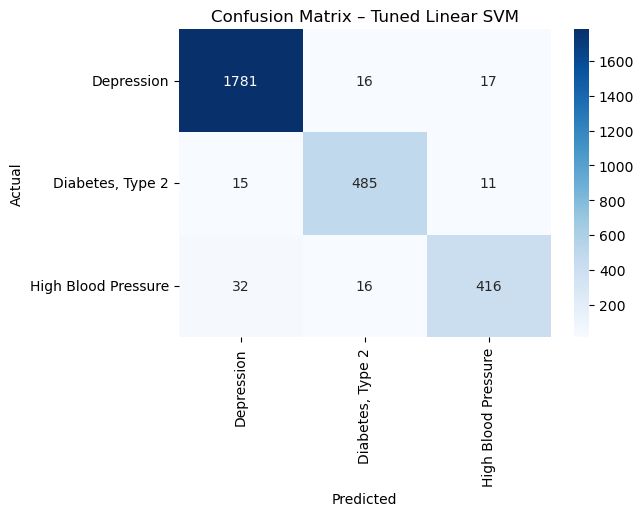

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Tuned Linear SVM")
plt.show()


In [39]:
import pickle

# Save trained condition classification model
with open("linear_svm_tuned.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model and artifacts saved successfully.")


Model and artifacts saved successfully.


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# user input
user_review = "I was on Bydureon for about 2 months, I really noticed the loss of appetite and lost my sweet tooth.My weight came down and my blood sugar levels dropped from 8.5 to 6.0. I was really happy with the medicine until the known side effects started to show. They were nausea this happened approx once a week in the fourth week in on taking the medicine and bloating, indigestion, a lot of passing wind and acidy burps. Also I felt a bump and itchy feeling around injection area whenever I injected. If they can sort out these side effects then it would be really fantastic for people with Type 2 diabetes. I was really reluctant to stop but the horrible nausea beat me.  "

# Condition prediction
user_vec = tfidf.transform([user_review])
cond_pred = best_model.predict(user_vec)
condition = le.inverse_transform(cond_pred)[0]

# Sentiment prediction using VADER
sentiment_score = sia.polarity_scores(user_review)['compound']

if sentiment_score >= 0.05:
    sentiment = "Positive"
elif sentiment_score <= -0.05:
    sentiment = "Negative"
else:
    sentiment = "Neutral"

print("Predicted Condition:\n", condition)
print("Predicted Sentiment:\n", sentiment)


Predicted Condition:
 Diabetes, Type 2
Predicted Sentiment:
 Negative
